In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

## Series de Tiempo

Las series de tiempo son un tipo de datos que se registran en intervalos de tiempo regulares (por ejemplo, cada día, mes, año, segundo, etc.) y cuyo orden cronológico es fundamental. En otras palabras, una serie de tiempo es una secuencia de observaciones ordenadas temporalmente.

<b>Características principales</b>

* <b>Orden temporal:</b> El tiempo es el eje principal. No se pueden mezclar los datos sin perder información.

* <b>Dependencia temporal:</b> Los valores pasados pueden influir en los futuros.

* <b>Tendencia:</b> Cambio a largo plazo (por ejemplo, aumento constante de precios).

* <b>Estacionalidad:</b> Patrones que se repiten regularmente (como ventas que suben cada diciembre).

* <b>Ruido:</b> Variaciones aleatorias no explicables.




In [2]:
# Datos del indice dow jones de la bolsa de valores

df = pd.read_csv('../dataset/dow.csv')
df

,Fecha,Día,Ranking,Diario,Variación,Diferencia,Pronóstico,Cambio Porcentual,Vol,A la fecha,ID
0,26-Apr-21,Viernes,1,"$125,789.89",NaN,-,"$235,036.46",-46.48%,1000,"$125,789.89",1
1,27-Apr-21,Sábado,1,"$99,374.01",79.00%,-26416,"$197,622.55",-49.72%,1000,"$225,163.90",2
2,28-Apr-21,Domingo,1,"$82,203.16",82.72%,-17171,"$116,991.26",-29.74%,1000,"$307,367.06",3
3,29-Apr-21,Lunes,1,"$33,530.26",40.79%,-48673,"$66,652.65",-49.69%,1000,"$340,897.32",4
4,30-Apr-21,Martes,1,"$30,105.24",89.79%,-3425,"$34,828.19",-13.56%,1000,"$371,002.56",5
...,...,...,...,...,...,...,...,...,...,...,...
123,27-Aug-21,Martes,42,$0.00,29.03%,0,$0.01,-45.07%,100,"$752,143.86",124
124,28-Aug-21,Miércoles,43,$0.00,49.60%,0,$0.00,-32.94%,100,"$752,143.87",125
125,29-Aug-21,Viernes,42,$0.00,29.03%,0,$0.00,-38.06%,100,"$752,143.87",126
126,30-Aug-21,Viernes,36,$0.00,49.60%,0,$0.00,-24.58%,100,"$752,143.87",127


In [3]:
df = pd.read_csv('../dataset/dow.csv',parse_dates=['Fecha'],index_col='Fecha', 
                 usecols=['Fecha', 'Diario', 'Pronóstico', 'Cambio Porcentual'])
df

,Diario,Pronóstico,Cambio Porcentual
Fecha,,,
2021-04-26,"$125,789.89","$235,036.46",-46.48%
2021-04-27,"$99,374.01","$197,622.55",-49.72%
2021-04-28,"$82,203.16","$116,991.26",-29.74%
2021-04-29,"$33,530.26","$66,652.65",-49.69%
2021-04-30,"$30,105.24","$34,828.19",-13.56%
...,...,...,...
2021-08-27,$0.00,$0.01,-45.07%
2021-08-28,$0.00,$0.00,-32.94%
2021-08-29,$0.00,$0.00,-38.06%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 128 entries, 2021-04-26 to 2021-08-31
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Diario             128 non-null    object
 1   Pronóstico         128 non-null    object
 2   Cambio Porcentual  128 non-null    object
dtypes: object(3)
memory usage: 4.0+ KB


#### Por ejemplo, podemos eliminar el símbolo "$" y convertir a formato *float* las columnas `Diario` y `Pronóstico`. Para ello podemos usar funciones lambda y la función `apply()

In [5]:
limpiar = lambda x: x.str.replace('[^\d]', '', regex=True)  # [^\d]: buscar caracteres no numéricos
df_c = df[['Diario', 'Pronóstico']].apply(limpiar, axis=1)# Aplicar función anterior
df[['Diario', 'Pronóstico']] = df_c.astype(float)         # Reemplazar columnas originales por columnas procesadas
df

,Diario,Pronóstico,Cambio Porcentual
Fecha,,,
2021-04-26,12578989.0,23503646.0,-46.48%
2021-04-27,9937401.0,19762255.0,-49.72%
2021-04-28,8220316.0,11699126.0,-29.74%
2021-04-29,3353026.0,6665265.0,-49.69%
2021-04-30,3010524.0,3482819.0,-13.56%
...,...,...,...
2021-08-27,0.0,1.0,-45.07%
2021-08-28,0.0,0.0,-32.94%
2021-08-29,0.0,0.0,-38.06%


In [6]:
# Remover porcentaje 
df['Cambio Porcentual'] = df['Cambio Porcentual'].apply(lambda x: x.replace('%', '')).astype(float)
df

,Diario,Pronóstico,Cambio Porcentual
Fecha,,,
2021-04-26,12578989.0,23503646.0,-46.48
2021-04-27,9937401.0,19762255.0,-49.72
2021-04-28,8220316.0,11699126.0,-29.74
2021-04-29,3353026.0,6665265.0,-49.69
2021-04-30,3010524.0,3482819.0,-13.56
...,...,...,...
2021-08-27,0.0,1.0,-45.07
2021-08-28,0.0,0.0,-32.94
2021-08-29,0.0,0.0,-38.06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 128 entries, 2021-04-26 to 2021-08-31
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Diario             128 non-null    float64
 1   Pronóstico         128 non-null    float64
 2   Cambio Porcentual  128 non-null    float64
dtypes: float64(3)
memory usage: 4.0 KB


### Visualización

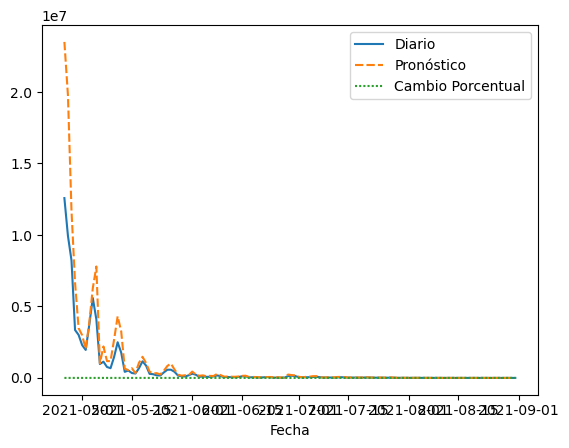

In [8]:
ax = sns.lineplot(df)

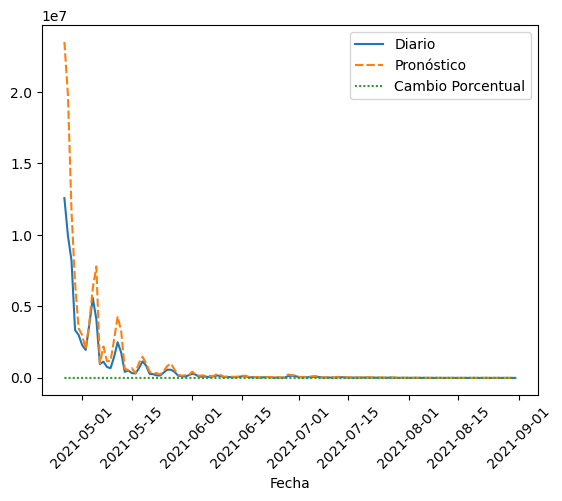

In [9]:
ax = sns.lineplot(df)
plt.xticks(rotation=45);

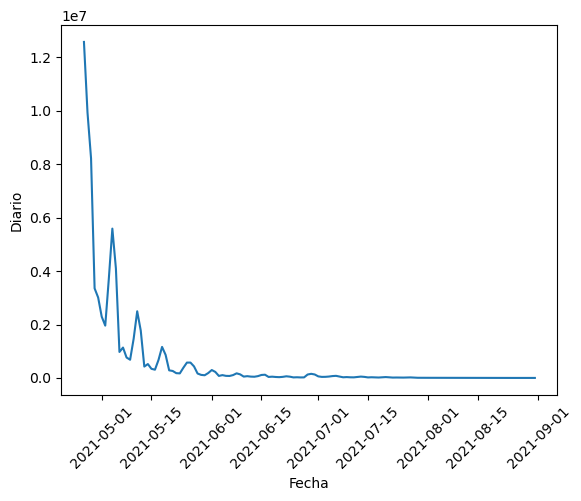

In [10]:
ax = sns.lineplot(df['Diario'])
plt.xticks(rotation=45);

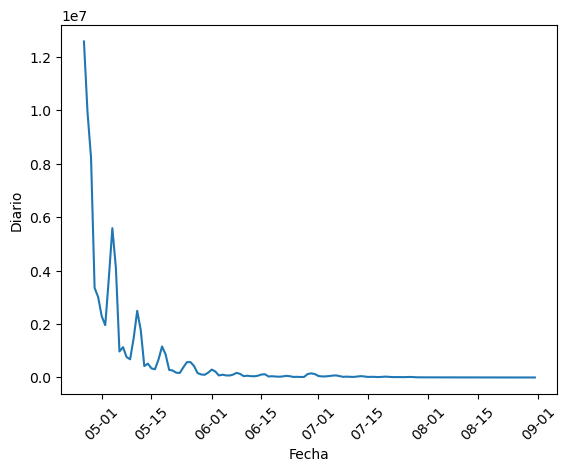

In [11]:
# Mostrar sólo mes-día (no año)

# Generemos el gráfico anterior
ax = sns.lineplot(data=df['Diario'])

# "DateFormatter" para especificar el formato con el que queremos mostrar
# las marcas de tiempo
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Y finalmente rotemos las etiquetas
plt.xticks(rotation=45);

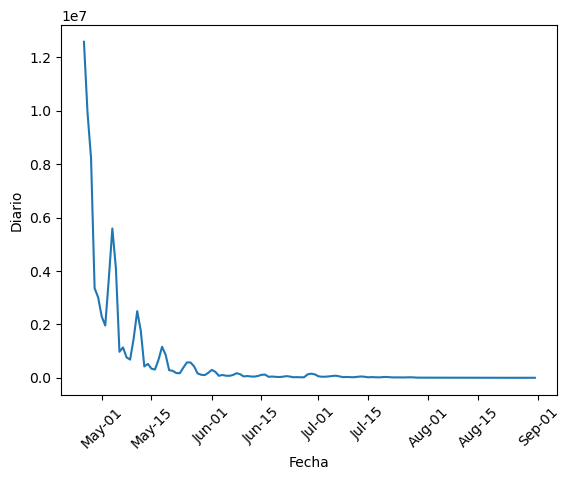

In [12]:
# En lugar del númnero del mes mostrar sus iniciales
ax = sns.lineplot(data=df['Diario'])

# Y ahora usemos "DateFormatter" para especificar el formato con el que queremos mostrar
# las marcas de tiempo
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

# Y finalmente rotemos las etiquetas
plt.xticks(rotation=45);

<Axes: xlabel='Fecha'>

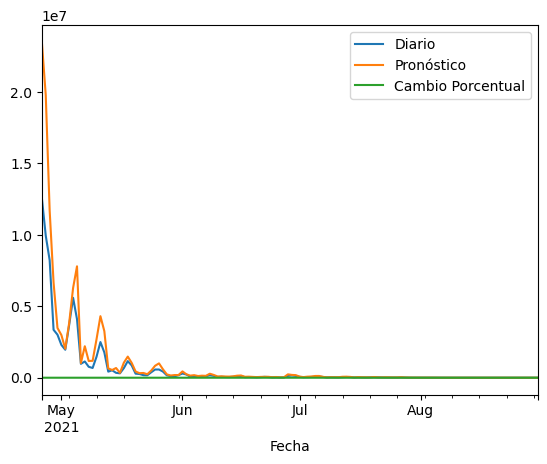

In [13]:
#ocupar pandas
df.plot()

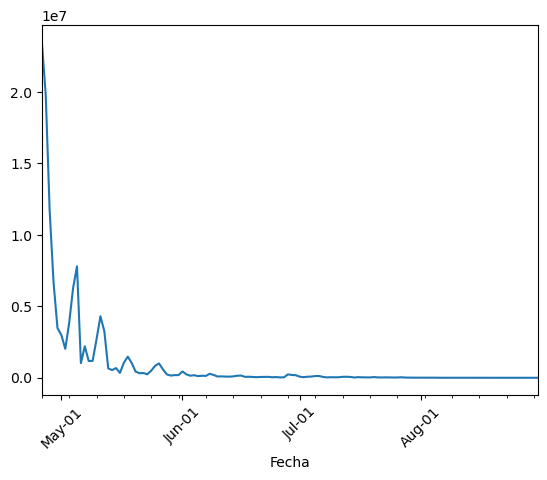

In [14]:
# Mostrar Serie de Tiempo "Pronóstico"
ax = df['Pronóstico'].plot();

# Mostrar cada marca de tiempo como las iniciales del mes y el día
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

# Usemos "DayLocator" y el parámetro "interval" para especificar que las marcas de tiempo
# se mostrarán con periodicidad de 1 mes
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Y finalmente rotemos las etiquetas
plt.xticks(rotation=45);

### Datos que faltan en un Serie de Tiempo

Dataset

- *co2_faltantes.csv*: emisiones anuales (1750-2020) de dióxido de carbono  a la atmósfera provenientes de la quema de combustibles fósiles

<b>Información de interacción de usuarios (número de clicks) de un sitio web de artículos de vestuario.</b>

- *clicks-faltantes-marcas.csv*, 
- *clicks-faltantes-marcas-ocultas.csv* 
- *clicks-faltantes-multiples.csv*: 


In [15]:
co2_df = pd.read_csv('../dataset/co2_faltantes.csv',
                    parse_dates = ['año'],
                    index_col = ['año'])

clicks_df = pd.read_csv('../dataset/clicks_faltantes_marcas.csv',
                    parse_dates=['fecha'],
                    index_col = ['fecha'])

clicks_oc_df = pd.read_csv('../dataset/clicks_faltantes_marcas_ocultas.csv',
                    parse_dates=['fecha'],
                    index_col = ['fecha'])

clicks_mult_df = pd.read_csv('../dataset/clicks_faltantes_multiples.csv',
                             parse_dates = ['fecha'],
                             index_col = ['fecha'])

In [16]:
#Vemos que el tercer elemento de la columna "co2" contiene un dato faltante, marcado como NaN. 
co2_df


,co2
año,
1750-01-01,0.0125
1760-01-01,0.0128
1770-01-01,NaN
1780-01-01,0.0169
1790-01-01,0.0206
...,...
2016-01-01,4.7496
2017-01-01,4.7595
2018-01-01,4.8022


In [19]:
## Detección de observaciones faltantes
clicks_df.index.isna().sum()

np.int64(2)

In [20]:
clicks_oc_df

,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
2008-04-03,43.842609,2,15209.0
2008-04-05,43.941176,1,11974.0
2008-04-06,44.403936,1,11007.0
...,...,...,...
2008-08-09,44.182033,1,6716.0
2008-08-10,43.608260,1,9523.0
2008-08-11,43.553363,1,8881.0


In [21]:
clicks_oc_df.isna().sum()

precio        0
ubicación     0
clicks       16
dtype: int64

In [23]:
#Vemos que en principio hay un salto entre 2008-04-03 y 2008-04-05. 
#Es decir que la Serie de Tiempo tiene una frecuencia diaria pero esta frecuencia no se mantiene para 2008-04-04.
clicks_oc_df

,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
2008-04-03,43.842609,2,15209.0
2008-04-05,43.941176,1,11974.0
2008-04-06,44.403936,1,11007.0
...,...,...,...
2008-08-09,44.182033,1,6716.0
2008-08-10,43.608260,1,9523.0
2008-08-11,43.553363,1,8881.0


### Detección usando el método "difference"

En este caso la idea es:

1. Crear un rango ideal de fechas
2. Usar "difference" para encontrar las diferencias entre este rango y el índice original del DataFrame

In [24]:
# 1. Crear un rango completo de fechas
rango_fechas = pd.date_range(start=clicks_oc_df.index.min(), end=clicks_oc_df.index.max(), freq='D')
rango_fechas

DatetimeIndex(['2008-04-01', '2008-04-02', '2008-04-03', '2008-04-04',
               '2008-04-05', '2008-04-06', '2008-04-07', '2008-04-08',
               '2008-04-09', '2008-04-10',
               ...
               '2008-08-04', '2008-08-05', '2008-08-06', '2008-08-07',
               '2008-08-08', '2008-08-09', '2008-08-10', '2008-08-11',
               '2008-08-12', '2008-08-13'],
              dtype='datetime64[ns]', length=135, freq='D')

In [25]:
# 2. Usar "difference" para encontrar las diferencias entre este rango y el índice original del *DataFrame*
rango_fechas.difference(clicks_oc_df.index)

DatetimeIndex(['2008-04-04', '2008-04-07', '2008-04-09'], dtype='datetime64[ns]', freq=None)

## observaciones y marcas de tiempo faltantes

En este caso tendremos tanto observaciones faltantes (marcadas como *NaN*) como marcas de tiempo faltantes (marcadas o no como *NaT*).

In [26]:
clicks_mult_df

,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2.0,18784
2008-04-02,43.079056,1.0,24738
NaT,43.842609,NaN,15209
NaT,NaN,1.0,14018
NaT,43.941176,1.0,11974
...,...,...,...
2008-08-09,44.182033,1.0,6716
2008-08-10,43.608260,1.0,9523
2008-08-11,43.553363,1.0,8881


In [27]:
clicks_mult_df.isna().sum()


precio        1
ubicación     1
clicks       14
dtype: int64

In [28]:
#Y para el caso de las marcas de tiempo "NaT":
clicks_mult_df.index.isna().sum()

np.int64(4)

### Marcas de tiempo que faltan

Supongamos que tenemos esta Serie de Tiempo:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| NaT        | 0.9         |
| NaT        | 4.3         |
| NaT        | 1.3         |
| 2020-01-04 | 2.92        |

En este caso vemos que la Serie tiene una frecuencia diaria y que al parecer falta la marca correspondiente al 2020-01-03. Sin embargo, tenemos 3 observaciones que podrían pertenecer a esa marca.

En este caso podemos eliminar los registros consecutivos con "NaT" y crear uno nuevo con la(s) fecha(s) faltantes. En este caso aparecerá una observación tipo "NaN" que deberá ser manejada.


In [29]:
# Crear el DataFrame con múltiples marcas faltantes
ind = ['2020-01-01', '2020-01-02', 'NaT', 'NaT', 'NaT', '2020-01-04']
obs = [0.25, 3.27, 0.9, 4.3, 1.3, 2.92]
ind = pd.to_datetime(ind)
df = pd.DataFrame(obs, index=ind, columns=['Observación'])
df

,Observación
2020-01-01,0.25
2020-01-02,3.27
NaT,0.90
NaT,4.30
NaT,1.30
2020-01-04,2.92


In [30]:
# Eliminar registros cuyo índice sea "NaT"
# Esto equivale a preservar las filas cuyo índice NO SEA "NaT"
df_clean = df[pd.notna(df.index)]
df_clean

,Observación
2020-01-01,0.25
2020-01-02,3.27
2020-01-04,2.92


In [31]:
# Reindexar

# Ordenar el DataFrame original de manera ascendente según su índice (por precaución)
df_clean = df_clean.sort_index()

# Definir rango completo
rango_completo = pd.date_range(start=df_clean.index.min(), end=df_clean.index.max(), freq='D')
print(rango_completo)

# Reindexar con base en el rango completo
df_clean = df_clean.reindex(rango_completo)

print('DataFrame original:')
print(df)
print('='*30)
print('DataFrame pre-procesado:')
print(df_clean)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04'], dtype='datetime64[ns]', freq='D')
DataFrame original:
            Observación
2020-01-01         0.25
2020-01-02         3.27
NaT                0.90
NaT                4.30
NaT                1.30
2020-01-04         2.92
DataFrame pre-procesado:
            Observación
2020-01-01         0.25
2020-01-02         3.27
2020-01-03          NaN
2020-01-04         2.92


### Hay correspondencia entre las marcas faltantes y la frecuencia de la serie

Supongamos que tenemos esta Serie de Tiempo:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| NaT        | 0.9         |
| 2020-01-04 | 4.3         |
| NaT        | 1.3         |
| 2020-01-06 | 2.92        |

En este caso vemos que la Serie tiene una frecuencia diaria y que al parecer faltan las marcas correspondiente al 2020-01-03 y 2020-01-05, para cada una de las cuales tenemos exactamente 1 observación.

En este caso podemos:

1. Definir un nuevo índice con el rango específico de fechas (inicio-final)
2. Fijar este nuevo índice como índice del *DataFrame* existente

In [32]:
# Crear el DataFrame con marcas faltantes
ind = ['2020-01-01', '2020-01-02', 'NaT', '2020-01-04', 'NaT', '2020-01-06']
obs = [0.25, 3.27, 0.9, 4.3, 1.3, 2.92]
ind = pd.to_datetime(ind)
df = pd.DataFrame(obs, index=ind, columns=['Observación'])
df

,Observación
2020-01-01,0.25
2020-01-02,3.27
NaT,0.90
2020-01-04,4.30
NaT,1.30
2020-01-06,2.92


In [33]:
# 1. Crear un rango completo de fechas
rango_completo = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
rango_completo

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06'],
              dtype='datetime64[ns]', freq='D')

In [34]:
# 2. Fijar el nuevo índice como índice del DataFrame existente
df_clean = df.set_index(rango_completo)

print('Dataframe original: ')
print(df)
print('='*30)
print('Dataframe pre-procesado: ')
print(df_clean)

Dataframe original: 
            Observación
2020-01-01         0.25
2020-01-02         3.27
NaT                0.90
2020-01-04         4.30
NaT                1.30
2020-01-06         2.92
Dataframe pre-procesado: 
            Observación
2020-01-01         0.25
2020-01-02         3.27
2020-01-03         0.90
2020-01-04         4.30
2020-01-05         1.30
2020-01-06         2.92


### Manejo de marcas de tiempo faltantes "ocultas"

Recordemos que en este caso ninguna marca de tiempo aparece etiquetada como *NaT* y sin embargo tendremos marcas faltantes.

Por ejemplo el *DataFrame*:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| 2020-01-04 | 2.92        |

No contiene *NaT*s en su índice y sin embargo falta el registro correspondiente a la fecha 2022-01-03.

En este caso podemos reindexar la Serie de Tiempo teniendo en cuenta que **se agregarán tantos NaN a las observaciones como elementos se añadan al índice original**.

In [35]:
# Crear el DataFrame con marcas faltantes
ind = ['2020-01-01', '2020-01-02', '2020-01-04']
obs = [0.25, 3.27, 2.92]
ind = pd.to_datetime(ind)
df = pd.DataFrame(obs, index=ind, columns=['Observación'])
df

,Observación
2020-01-01,0.25
2020-01-02,3.27
2020-01-04,2.92


In [36]:
# Ordenar la serie de manera ascendente según su índice (por precaución)
df_clean = df.sort_index()

# Crear nuevo índice
rango_completo = pd.date_range(start=df_clean.index.min(), end=df_clean.index.max(), freq='D')

# Reindexar
df_clean = df_clean.reindex(rango_completo)

print('Dataframe original: ')
print(df)
print('='*30)
print('Dataframe pre-procesado: ')
print(df_clean)

Dataframe original: 
            Observación
2020-01-01         0.25
2020-01-02         3.27
2020-01-04         2.92
Dataframe pre-procesado: 
            Observación
2020-01-01         0.25
2020-01-02         3.27
2020-01-03          NaN
2020-01-04         2.92


Vemos que en el caso anterior tan sólo había una marca faltante entre las fechas 2020-01-02 y 2020-01-04 y por tanto se agregó tan sólo una observación (NaN) en la nueva Serie de Tiempo.

Sin embargo, **este método no es aconsejable cuando tenemos bloques de tiempo demasiado grandes en comparación con la frecuencia de la Serie**.

Por ejemplo, si ahora la Serie de Tiempo es de la forma:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| 2020-01-08 | 2.92        |

Vemos que entre 2020-01-02 y 2020-01-08 ahora tendremos 5 marcas de tiempo faltantes. Por tanto, si usamos el método anterior añadiremos 5 observaciones tipo NaN que más adelante tendremos que manejar.

Esto no es recomendable porque tendremos un exceso de valores NaN por manejar para los cuales no tenemos suficiente información que nos permita completarlos.

En este caso se sugiere adquirir nuevamente los datos (de ser posible).

### Ejemplo

In [39]:
# Leer dataset

df = pd.read_csv('../dataset/clicks_faltantes_marcas.csv',
                 parse_dates = ['fecha'],
                 index_col = ['fecha'])
df

,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
NaT,43.842609,2,15209.0
2008-04-04,43.382794,2,14320.0
2008-04-05,43.941176,1,11974.0
...,...,...,...
2008-08-09,44.182033,1,6716.0
2008-08-10,43.608260,1,9523.0
2008-08-11,43.553363,1,8881.0


In [40]:
# NaN
df.index.isna().sum()

np.int64(2)

In [41]:
#Veamos dónde deberían estar ubicadas idealmente:

# DataFrame sin marcas NaT ordenado de manera ascendente
df_sin_nat = df[pd.notna(df.index)].sort_index()

# Rango de fechas ideal
rango_fechas = pd.date_range(start=df_sin_nat.index.min(), end=df_sin_nat.index.max(), freq='D')

# Diferencia entre el rango de fechas ideal y el índice de la Serie de Tiempo
rango_fechas.difference(df_sin_nat.index)

DatetimeIndex(['2008-04-03', '2008-04-07', '2008-04-09'], dtype='datetime64[ns]', freq=None)

In [ ]:
#Vemos que en realidad son 3 las marcas de tiempo faltantes, aunque el uso de `clicks_df.index.isna().sum()` nos indicaba que eran 2.
#Veamos en detalle esta porción de la Serie de Tiempo:


In [42]:
df.iloc[0:10,:]

,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
NaT,43.842609,2,15209.0
2008-04-04,43.382794,2,14320.0
2008-04-05,43.941176,1,11974.0
2008-04-06,44.403936,1,11007.0
NaT,43.995888,2,15214.0
2008-04-08,43.373773,1,11333.0
2008-04-10,43.154738,5,15677.0


En este caso vemos que las marcas correspondientes a 2008-04-03 y 2008-04-07 están marcadas como *NaT*. Sin embargo hay una tercera marca faltante que está oculta y que corresponde a 2008-04-09.

Es decir que tenemos dos situaciones en este caso:

- 2 marcas faltantes tipo "NaT"
- 1 marca faltante "oculta"

Posibles soluciones:

1. Si intentamos reindexar la serie con el rango de fechas ideal aparecerá un error pues tendremos 2 marcas "NaT"
2. Si intentamos fijar el índice de la serie como el rango de fechas ideal aparecerá un error pues este rango ideal tendrá 1 registro adicional (correspondiente a la marca oculta faltante)

Así que en este caso podríamos:

1. Crear el índice ideal **eliminando la fecha correspondiente a 2008-04-09 (marca oculta)**
2. Usar el resultado de (1) para fijar el nuevo índice del *DataFrame*. En este punto ya habremos completado las marcas "NaT"
3. Crear el índice ideal incluyendo la marca oculta (2008-04-09) y reindexar el *DataFrame* obtenido en (2). En este punto habremos completado la marca oculta y habremos agregado tres observación *NaN* en la fila correspondiente.


In [43]:
# 1. Crear el índice ideal eliminando la fecha correspondiente a 2008-04-09 (marca oculta)

ind_ideal = pd.date_range(start=df_sin_nat.index.min(), end=df_sin_nat.index.max(), freq='D')
ind_filtrado = ind_ideal[ind_ideal != '2008-04-09']
ind_filtrado

DatetimeIndex(['2008-04-01', '2008-04-02', '2008-04-03', '2008-04-04',
               '2008-04-05', '2008-04-06', '2008-04-07', '2008-04-08',
               '2008-04-10', '2008-04-11',
               ...
               '2008-08-04', '2008-08-05', '2008-08-06', '2008-08-07',
               '2008-08-08', '2008-08-09', '2008-08-10', '2008-08-11',
               '2008-08-12', '2008-08-13'],
              dtype='datetime64[ns]', length=134, freq=None)

In [44]:
# 2. Usar el resultado de (1) para fijar el nuevo índice del DataFrame.
# En este punto ya habremos completado las marcas "NaT"

df_clean = df.set_index(ind_filtrado)

print('Dataframe original (posiciones 0:10):')
print(df.iloc[0:10,:])
print('='*30)
print('Dataframe preprocesado (posiciones 0:10):')
print(df_clean.iloc[0:10,:])

Dataframe original (posiciones 0:10):
               precio  ubicación   clicks
fecha                                    
2008-04-01  43.155647          2  18784.0
2008-04-02  43.079056          1  24738.0
NaT         43.842609          2  15209.0
2008-04-04  43.382794          2  14320.0
2008-04-05  43.941176          1  11974.0
2008-04-06  44.403936          1  11007.0
NaT         43.995888          2  15214.0
2008-04-08  43.373773          1  11333.0
2008-04-10  43.154738          5  15677.0
2008-04-11  42.921659          2  10792.0
Dataframe preprocesado (posiciones 0:10):
               precio  ubicación   clicks
2008-04-01  43.155647          2  18784.0
2008-04-02  43.079056          1  24738.0
2008-04-03  43.842609          2  15209.0
2008-04-04  43.382794          2  14320.0
2008-04-05  43.941176          1  11974.0
2008-04-06  44.403936          1  11007.0
2008-04-07  43.995888          2  15214.0
2008-04-08  43.373773          1  11333.0
2008-04-10  43.154738          5  1567

In [45]:
# 3. Crear el índice ideal incluyendo la marca oculta (2008-04-09) y reindexar
# el DataFrame obtenido en (2). En este punto habremos completado la marca oculta
# y habremos agregado tres observaciones NaN en la fila correspondiente.

# El índice ideal está en el arreglo "ind_ideal". Reindexación:
df_clean = df_clean.reindex(ind_ideal)

print('Dataframe original (posiciones 0:10):')
print(df.iloc[0:10,:])
print('='*30)
print('Dataframe preprocesado (posiciones 0:10):')
print(df_clean.iloc[0:10,:])

Dataframe original (posiciones 0:10):
               precio  ubicación   clicks
fecha                                    
2008-04-01  43.155647          2  18784.0
2008-04-02  43.079056          1  24738.0
NaT         43.842609          2  15209.0
2008-04-04  43.382794          2  14320.0
2008-04-05  43.941176          1  11974.0
2008-04-06  44.403936          1  11007.0
NaT         43.995888          2  15214.0
2008-04-08  43.373773          1  11333.0
2008-04-10  43.154738          5  15677.0
2008-04-11  42.921659          2  10792.0
Dataframe preprocesado (posiciones 0:10):
               precio  ubicación   clicks
2008-04-01  43.155647        2.0  18784.0
2008-04-02  43.079056        1.0  24738.0
2008-04-03  43.842609        2.0  15209.0
2008-04-04  43.382794        2.0  14320.0
2008-04-05  43.941176        1.0  11974.0
2008-04-06  44.403936        1.0  11007.0
2008-04-07  43.995888        2.0  15214.0
2008-04-08  43.373773        1.0  11333.0
2008-04-09        NaN        NaN      

#### Y vemos que este último paso del pre-procesamiento ha generado 3 observaciones *NaN* en la fecha correspondiente a 2008-04-09. Estas tres observaciones faltantes tendremos que manejarlas usando alguna tecnica

# Imputación univariada

La primera técnica de manejo de observaciones faltantes en una Serie de Tiempo: la imputación univariada.

El manejo de datos faltantes se reduce esencialmente a dos opciones:

- La imputación que consiste en usar los registros conocidos en la Serie de Tiempo para intentar completar los datos faltantes
- La eliminación de los registros faltantes que debemos realizar cuando ninguna de las técnicas de imputación arroja resultados adecuados.

Nos enfocaremos en la imputación univariada, donde este último término se refiere a que usaremos la propia observación que contiene registros incompletos para determinar los valores faltantes. El hecho de usar la propia observación implica que usaremos sólo una variable para realizar la imputación: de allí el término "imputación univariada".

Usaremos la librería Pandas.

In [46]:
# Esta función nos ayuda a visualizar la serie de tiempo antes y despues de una imputación

def graficar_serie(df, obs='', titulo=''):
    '''
    Permite graficar la Serie de Tiempo y mostrar simultáneamente
    sus valores extremos.
    
    Parámetros:
    - df: DataFrame de Pandas con la(s) Serie(s) de Tiempo
    - obs: nombre de la columna a graficar
    - titulo: el título del gráfico
    '''
    # Gráfico vacío
    fig, ax = plt.subplots(1,1)
    
    # Gráfico inicial
    if type(df) == pd.DataFrame:
        ax = sns.pointplot(data=df, x=df.index, y=obs, markers='')
    else:
        # Convertir Serie de Pandas a DataFrame de Pandas y graficar
        df = df.to_frame(name=obs) 
        ax = sns.pointplot(data=df, x=df.index, y=obs, markers='')
    
    # Dibujar sólo N=10 marcas temporales (en caso de tener series de tiempo)
    # con demasiadas marcas
    n_ticks = 10
    locator = mdates.AutoDateLocator(maxticks=n_ticks)
    ax.xaxis.set_major_locator(locator)
   
    # Rotar los ticks 45°
    plt.xticks(rotation=45)
    
    # Etiquetas ejes horizontal y vertical
    plt.xlabel('Tiempo')
    plt.ylabel(obs)
    plt.title(titulo);


            Valores
2020-04-01      1.0
2020-04-02      2.0
2020-04-03      NaN
2020-04-04      4.0
2020-04-05      NaN
2020-04-06      NaN
2020-04-07      3.0
2020-04-08      4.0
2020-04-09      9.0
2020-04-10     10.0


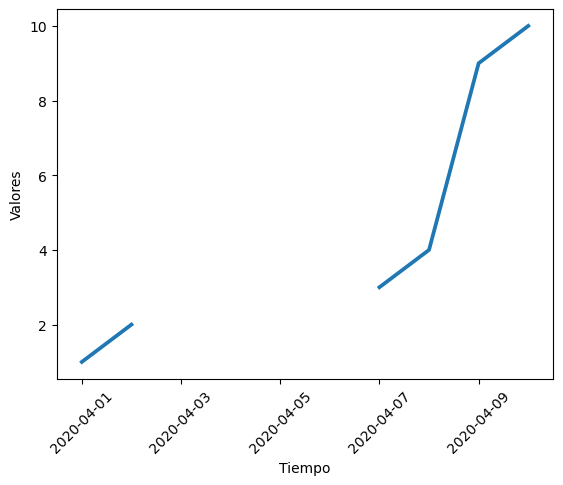

In [47]:
# Dataset de prueba
fechas = pd.date_range(start='2020-04-01', end='2020-04-10')
datos = [1, 2, None, 4, None, None, 3, 4, 9, 10]
df = pd.DataFrame(datos, index=fechas, columns=['Valores'])
print(df)

# Graficar
graficar_serie(df, obs='Valores')

### Ejemplo

En este caso usaremos los sets:

- *co2_faltantes.csv*: registro histórico de niveles de CO2 en la atmósfera
- *clicks_obs_faltantes.csv*: información de interacción de usuarios (número de clicks) de un sitio web de artículos de vestuario.


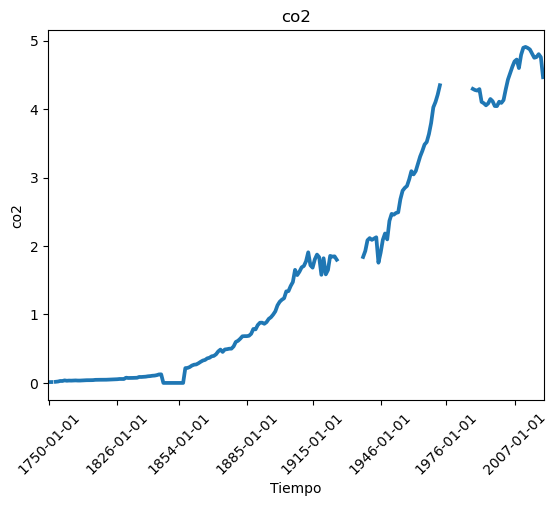

In [49]:
# Leer dataset co2_faltantes.csv

co2_df = pd.read_csv('../dataset/co2_faltantes.csv',
                    parse_dates = ['año'],
                    index_col = ['año'])
graficar_serie(co2_df, 'co2', 'co2')

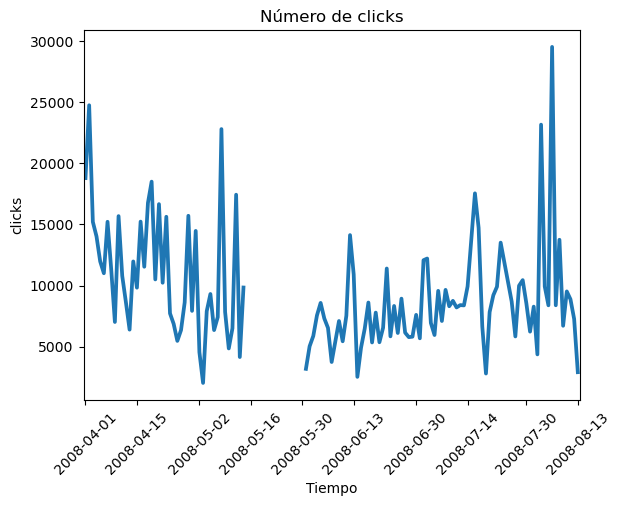

In [50]:
clicks_df = pd.read_csv('../dataset/clicks_obs_faltantes.csv',
                       parse_dates = ['fecha'],
                       index_col = ['fecha'])
graficar_serie(clicks_df, 'clicks', 'Número de clicks')

### Imputación univariada usando Pandas

La idea es usar los valores conocidos en la variable observada para imputar los valores faltantes. En particular podemos:

- Realizar imputación por la media
- Realizar imputación por llenado hacia adelante: tomar el valor de la última observación (antes del dato faltante) para realizar la imputación.
- Realizar la imputación por llenado hacia atrás: tomar el valor de la siguiente observación (después del dato faltante) para realizar la imputación.

Ocuparemos primero Pandas

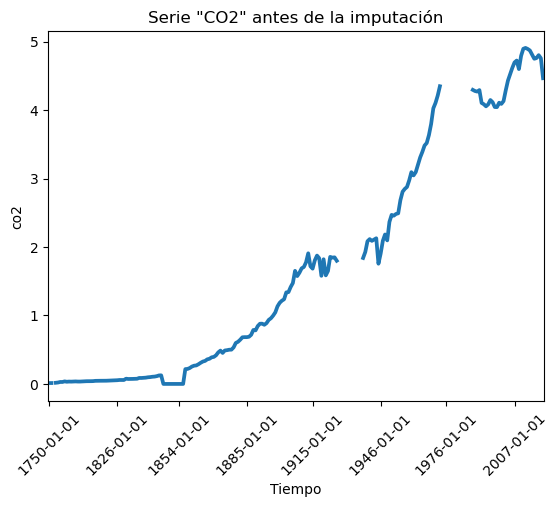

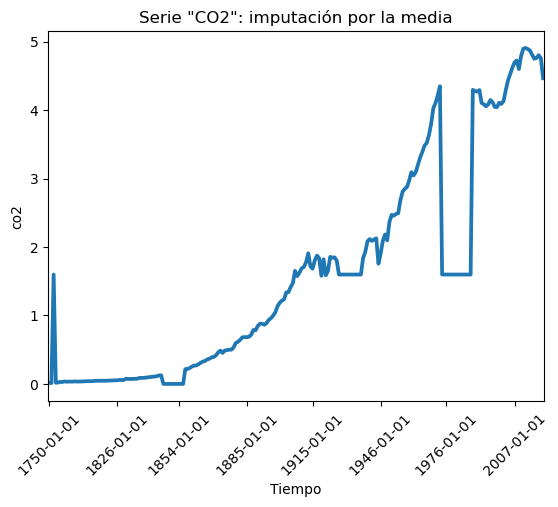

In [51]:
# Imputación por la media
co2_df_imp = co2_df['co2'].fillna(co2_df['co2'].mean())

# Gráficos antes y después de la imputación
graficar_serie(co2_df, obs='co2', titulo='Serie "CO2" antes de la imputación')
graficar_serie(co2_df_imp, obs='co2', titulo='Serie "CO2": imputación por la media')



### En este caso vemos que la imputación por la media no resulta adecuada pues la Serie tiene tendencia y por tanto su media es relativamente constante a pesar de que los valores de la Serie se incrementan a lo largo del tiempo.

Veamos esta misma imputación pero en la serie *clicks_df*:

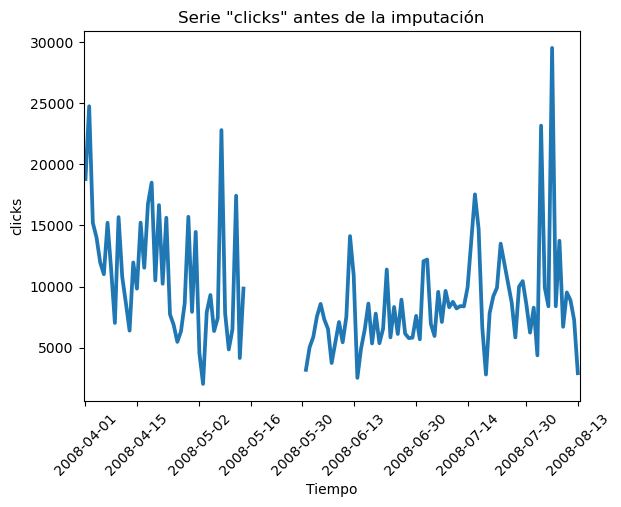

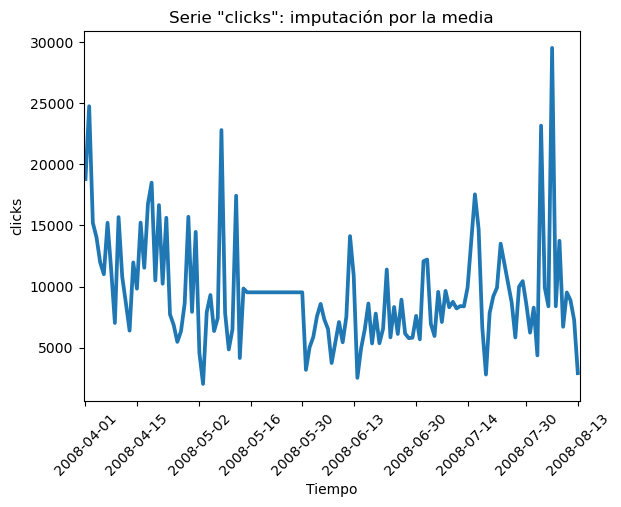

In [52]:
# Imputación por la media
clicks_df_imp = clicks_df['clicks'].fillna(clicks_df['clicks'].mean())

# Gráficos antes y después de la imputación
graficar_serie(clicks_df, obs='clicks', titulo='Serie "clicks" antes de la imputación')
graficar_serie(clicks_df_imp, obs='clicks', titulo='Serie "clicks": imputación por la media')

En este caso vemos que tampoco resulta adecuada la imputación por la media puesto que a pesar de que la Serie no tiene tendencia sí posee muchas variaciones entre instantes de tiempo consecutivos.

Así que podemos resumir lo siguiente:

> **La imputación por la media funciona adecuadamente cuando tenemos pocas variaciones en la Serie o cuando esta NO tiene tendencia o estacionalidad**

### Imputación por llenado hacia adelante (*forward fill*)

Consiste en tomar el valor de la última observación (antes del dato faltante) para realizar la imputación.

Por ejemplo, en la Serie:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| 2020-01-03 | NaN         |
| 2020-01-04 | NaN         |
| 2020-01-05 | 3.22        |
| 2020-01-06 | 3.24        |

La última observación antes del primer dato faltante es igual a 3.27. Así que usamos este valor para completar los dos datos faltantes siguientes. Entonces la serie con valores imputados sería:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| 2020-01-03 | **3.27**         |
| 2020-01-04 | **3.27**       |
| 2020-01-05 | 3.22        |
| 2020-01-06 | 3.24        |

Para realizar esta imputación en Pandas podemos seguir usando el método `fillna()` y agregar el parámetro `method = 'ffill'`.

Veamos cómo realizar la imputación sobre la Serie *co2_df*:

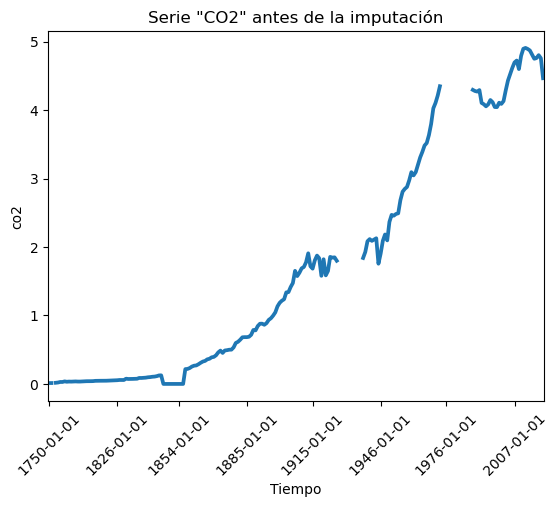

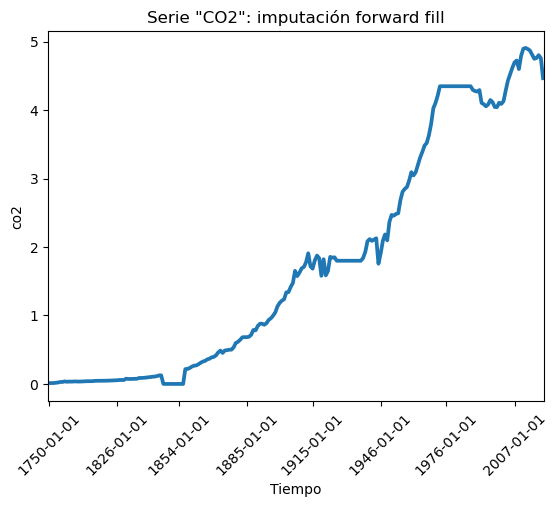

In [53]:
# Imputación "forward fill"
co2_df_imp = co2_df['co2'].fillna(method='ffill')

# Gráficos antes y después de la imputación
graficar_serie(co2_df, obs='co2', titulo='Serie "CO2" antes de la imputación')
graficar_serie(co2_df_imp, obs='co2', titulo='Serie "CO2": imputación forward fill')

### En este caso vemos que la imputación preserva mejor las características de la Serie de Tiempo.

Realicemos ahora la imputación de la Serie *clicks_df*:

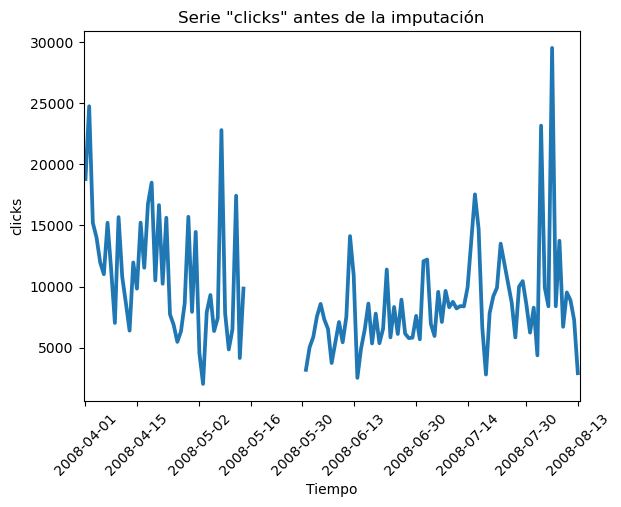

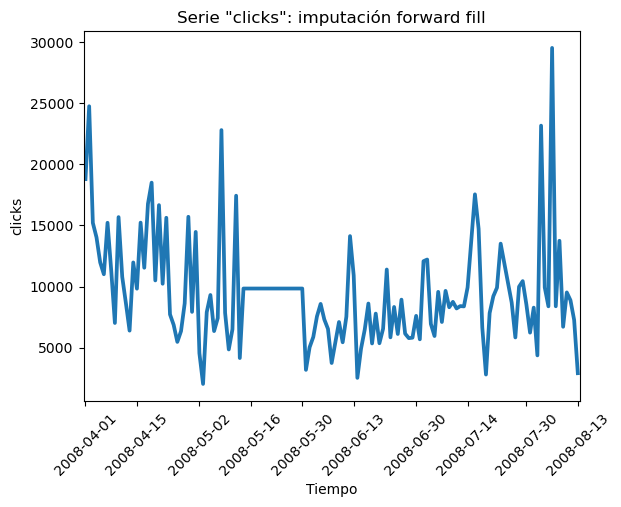

In [54]:
# Imputación con forward fill
clicks_df_imp = clicks_df['clicks'].fillna(method='ffill')

# Gráficos antes y después de la imputación
graficar_serie(clicks_df, obs='clicks', titulo='Serie "clicks" antes de la imputación')
graficar_serie(clicks_df_imp, obs='clicks', titulo='Serie "clicks": imputación forward fill')

Y en este caso ocurre algo similar a la imputación por la media.

Este método de llenado hacia adelante tiene un inconveniente: si el valor de referencia es un valor extremo (o muy grande o muy pequeño) la imputación generará igualmente un bloque de valores extremos.

Así que podemos resumir lo siguiente:

> **La imputación con llenado hacia adelante (*forward fill*) resulta adecuada si la Serie NO contiene valores extremos pero es mejor que la imputación por la media si la Serie tiene tendencia o estacionalidad**

### Imputación por llenado hacia atrás (*backward fill*)

Consiste en tomar el valor de la primera observación (después del dato faltante) para realizar la imputación.

Por ejemplo, en la Serie:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| 2020-01-03 | NaN         |
| 2020-01-04 | NaN         |
| 2020-01-05 | 3.22        |
| 2020-01-06 | 3.24        |

La primera observación antes del primer dato faltante es igual a 3.22. Así que usamos este valor para completar los dos datos faltantes siguientes. Entonces la serie con valores imputados sería:

|   Índice   | Observación |
|:----------:|:-----------:|
| 2020-01-01 | 0.25        |
| 2020-01-02 | 3.27        |
| 2020-01-03 | **3.22**         |
| 2020-01-04 | **3.22**       |
| 2020-01-05 | 3.22        |
| 2020-01-06 | 3.24        |

Para realizar esta imputación en Pandas podemos seguir usando el método `fillna()` y agregar el parámetro `method = 'bfill'`.

Veamos cómo realizar la imputación sobre la Serie *co2_df*:

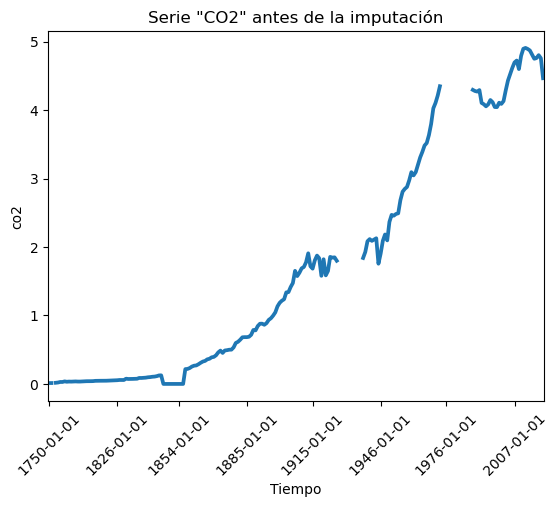

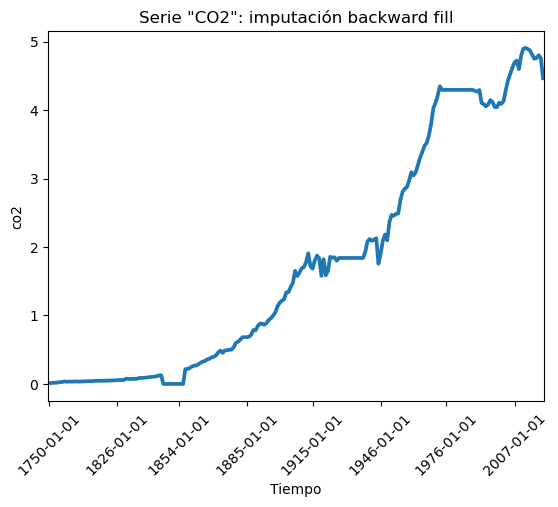

In [55]:
# Imputación "backward fill"
co2_df_imp = co2_df['co2'].fillna(method='bfill')

# Gráficos antes y después de la imputación
graficar_serie(co2_df, obs='co2', titulo='Serie "CO2" antes de la imputación')
graficar_serie(co2_df_imp, obs='co2', titulo='Serie "CO2": imputación backward fill')

### El resultado es muy parecido al obtenido con el llenado hacia adelante.
<!--  -->
Veamos lo que sucede al realizar esta imputación en la Serie *clicks_df*:

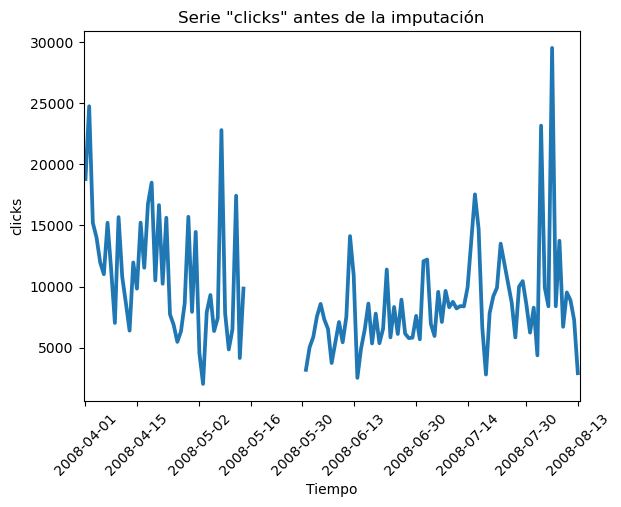

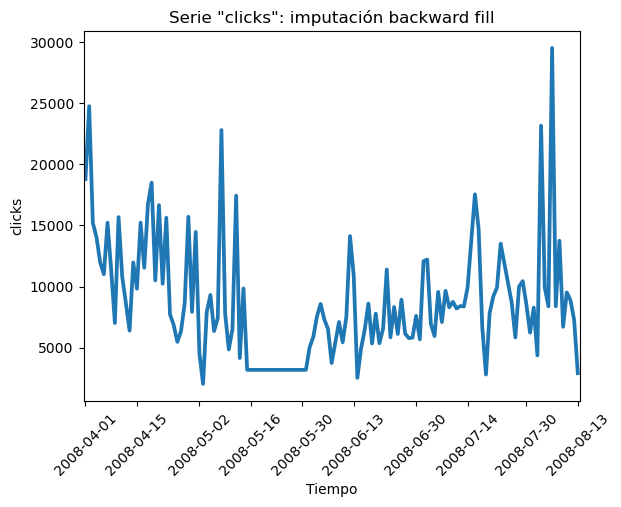

In [57]:
# Imputación con backward fill
clicks_df_imp = clicks_df['clicks'].fillna(method='bfill')

# Gráficos antes y después de la imputación
graficar_serie(clicks_df, obs='clicks', titulo='Serie "clicks" antes de la imputación')
graficar_serie(clicks_df_imp, obs='clicks', titulo='Serie "clicks": imputación backward fill')

### En este caso sí hay una diferencia en la imputación: los valores imputados con *backward fill* son menores (del orden de 2.500) que los obtenidos con la imputación *forward fill* (del orden de 10.000). Esto resalta la dependencia de estos dos métodos de los valores extremos.

## Conclusión

Partiendo de los ejemplos anteriores podemos resumir los posibles casos de uso de cada uno de los métodos que acabamos de ver:

1. La imputación por la media o por la mediana resultan adecuadas cuando la Serie de Tiempo NO tiene tendencia o estacionalidad y cuando no hay demasiadas variaciones entre valores consecutivos de la Serie.
2. La imputación por el valor más frecuente en general NO es recomendable: no preserva (en general) las variaciones de la Serie en diferentes instantes de tiempo.
3. Las imputaciones con llenado hacia adelante (*forward fill*) y hacia atrás (*backward fill*) son adecuadas cuando la Serie de Tiempo tiene tendencia o estacionalidad pero no son adecuadas cuando la Serie contiene valores extremos.

No hay un método ideal y que tendremos que ajustar el método de imputación univariada a las características propias de la Serie de Tiempo que estemos procesando. Sin embargo es importante tener en cuenta que cuando tenemos bloques con demasiadas observaciones faltantes, en general ningún método de imputación resultará siendo adecuado.